In [1]:
import xgboost
import shap
import pandas as pd
import numpy as np

/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
shap.initjs()

In [3]:
df = pd.read_csv("features_df.csv")[["Date", "Caudal", "Pluvio", "Nitratos", "Fosfatos", "Clorofila"]].dropna()
X = df[["Caudal","Pluvio", "Nitratos", "Fosfatos"]]
y = np.array(df["Clorofila"])

In [4]:
model = xgboost.XGBRegressor().fit(X, y)

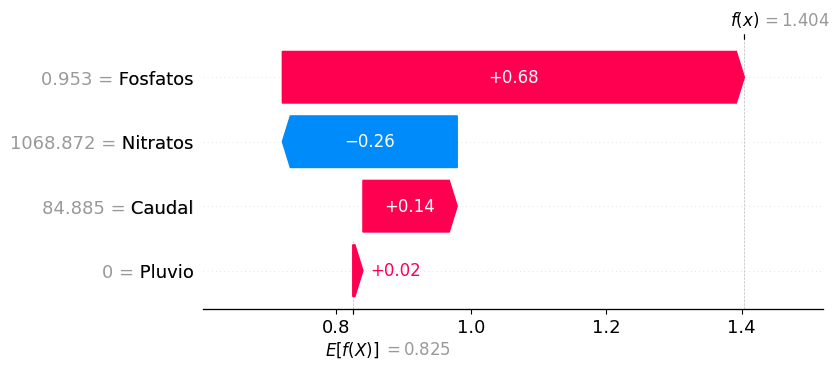

In [5]:
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Visualize the first prediction's explanation
shap.plots.waterfall(shap_values[2])

In [40]:
# visualize all the training set predictions
shap.plots.force(shap_values)

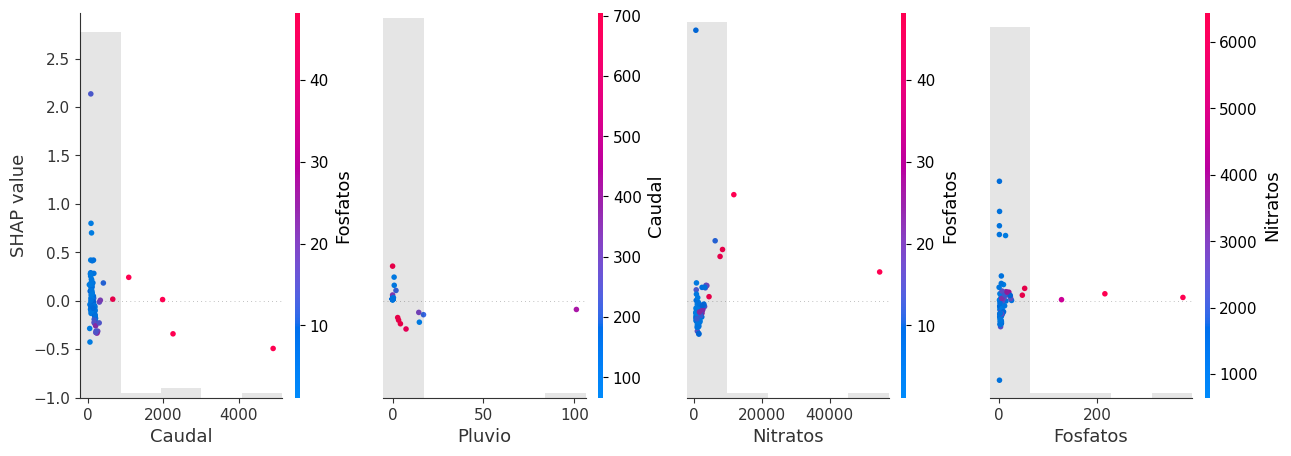

In [41]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values, color=shap_values)

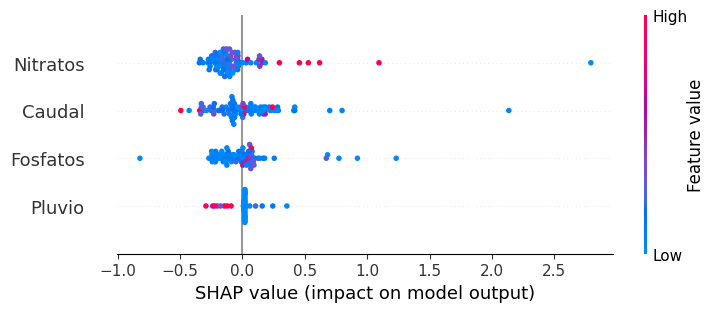

In [42]:
# summarize the effects of all the features
shap.plots.beeswarm(shap_values)

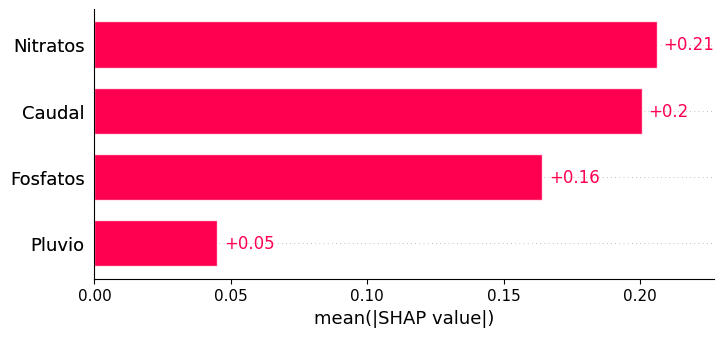

In [43]:
# mean absolute value of the SHAP values for each feature to get a standard bar plot (produces stacked bars for multi-class outputs):
shap.plots.bar(shap_values)